# Aprendizaje no supervisado

---




## Introducción
El aprendizaje no supervisado es una rama del Machine Learning en la que no contamos con etiquetas o respuestas conocidas. El algoritmo explora los datos y busca patrones, estructuras o agrupaciones por sí solo.

En lugar de decirle al modelo "este es un perro" o "esto es spam", simplemente le mostramos muchos datos y le pedimos que descubra relaciones o grupos interesantes.

| Aspecto             | Supervisado                 | No Supervisado                           |
| ------------------- | --------------------------- | ---------------------------------------- |
| Etiquetas conocidas | ✅ Sí (p. ej., spam/no spam) | ❌ No                                     |
| Objetivo principal  | Predecir una salida         | Descubrir patrones ocultos               |
| Ejemplos comunes    | Clasificación, regresión    | Clustering, reducción de dimensionalidad |
| Tipo de problemas   | Predictivos                 | Exploratorios                            |


---



## Reducción de Dimensionalidad

Esta técnica busca transformar datos con muchas columnas en un conjunto de datos de menor dimensionalidad, conservando la mayor cantidad posible de información.

### ¿Por qué es importante?

*   Ayuda a visualizar los datos en 2D o 3D
*   Elimina ruido o redundancias
*   Mejora el rendimiento de algunos modelos
*   Reduce el riesgo de sobreajuste (overfitting)


### Técnicas de reducción de dimensionalidad

1. PCA (Análisis de componentes principales): Transforma los datos para explicar la mayor varianza posible en menos dimensiones.

2. T-SNE: Reduce dimensiones manteniendo la similitud entre puntos cercanos. **Ideal para visualización.**


**🌟 En resumen:**

La reducción de dimensionalidad simplifica los datos sin perder su esencia. Es como pasar de un libro entero a un buen resumen que captura lo más importante.


| Característica       | **PCA**                              | **t-SNE**                                  |
| -------------------- | ------------------------------------ | ------------------------------------------ |
| Tipo                 | Lineal                               | No lineal                                  |
| Objetivo             | Capturar la **varianza global**      | Capturar la **estructura local** (vecinos) |            |
| Velocidad            | Muy rápido                           | Más lento                                  |
| Reutilizable para ML | ✅ (proyecta datos nuevos fácilmente) | ❌ (solo sirve para visualización)          |
| Ideal para           | Preprocesamiento y reducción técnica | Visualizar agrupaciones complejas          |

## Ejemplo práctico: Visualización del dataset Iris

In [ ]:
# Importamos librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [38]:
# Cargamos el dataset Iris
iris = load_iris()
X = iris.data  # datos (4 variables por flor)
y = iris.target  # etiquetas reales (para colorear los puntos)

In [46]:
categorias = pd.DataFrame(y, columns=['Especies'])
caracteristicas = pd.DataFrame(X, columns=iris.feature_names)
plantas = pd.concat([caracteristicas, categorias], axis=1)
plantas

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Especies
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [47]:
plantas.groupby('Especies').mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Especies,,,,
0,5.006,3.428,1.462,0.246
1,5.936,2.770,4.260,1.326
2,6.588,2.974,5.552,2.026


In [24]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Text(0.5, 1.0, 'Longitud del Sépalo por Clase')

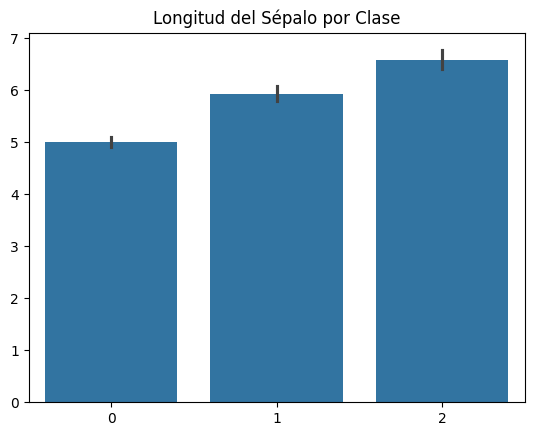

In [25]:
import seaborn as sns
sns.barplot(x=iris.target, y=iris.data[:, 0], estimator='mean')  # Graficamos la longitud del sépalo para cada clase
plt.title('Longitud del Sépalo por Clase')

Text(0.5, 1.0, 'Ancho del Sépalo por Clase')

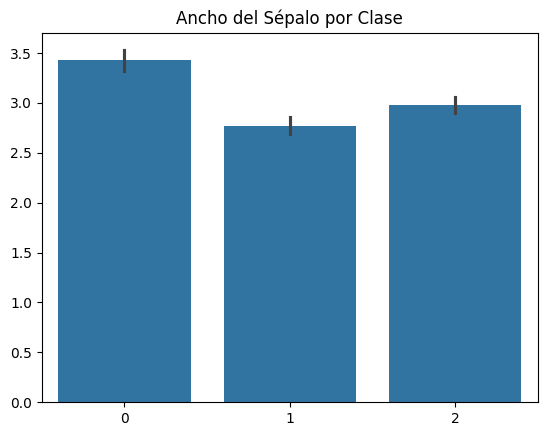

In [26]:
import seaborn as sns
sns.barplot(x=iris.target, y=iris.data[:, 1], estimator='mean')  # Graficamos la ancho del sépalo para cada clase
plt.title('Ancho del Sépalo por Clase')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24164\234306283.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=X[:,0], y=X[:,1], palette='Set1')


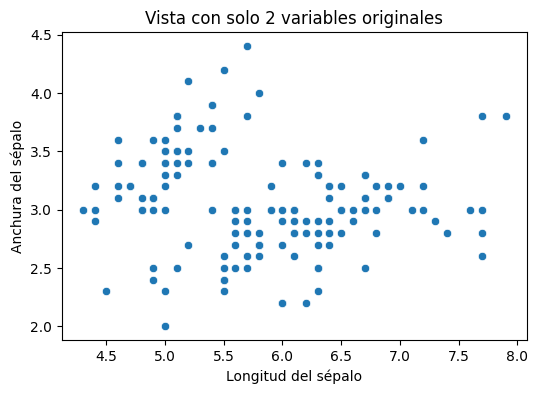

In [48]:
# Visualización original con solo las primeras dos variables (no es reducción real, solo una vista parcial)
plt.figure(figsize=(6,4))
sns.scatterplot(x=X[:,0], y=X[:,1], palette='Set1')
plt.title('Vista con solo 2 variables originales')
plt.xlabel('Longitud del sépalo')
plt.ylabel('Anchura del sépalo')
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24164\2339578914.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=X[:,2], y=X[:,3], palette='Set1')


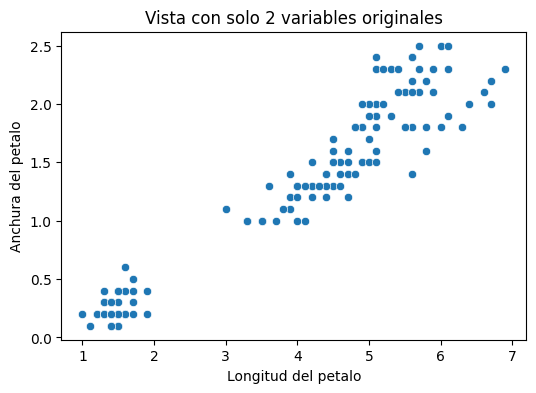

In [49]:
# Visualización original con solo las ultimas dos variables (no es reducción real, solo una vista parcial)
plt.figure(figsize=(6,4))
sns.scatterplot(x=X[:,2], y=X[:,3], palette='Set1')
plt.title('Vista con solo 2 variables originales')
plt.xlabel('Longitud del petalo')
plt.ylabel('Anchura del petalo')
plt.show()

In [ ]:
### REDUCCIÓN DE DIMENSIONALIDAD CON PCA
# Aplicamos PCA para reducir de 4D a 2D y visualizar los datos
from sklearn.decomposition import PCA

pca = PCA(2) # Conservamos el 96% de la varianza (puede ser un número o un porcentaje)
X_pca = pca.fit_transform(X)

In [30]:
X.shape

(150, 4)

In [51]:
X_pca.shape

(150, 2)

In [33]:
y.shape

(150,)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24164\1717041126.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], palette='Set2')


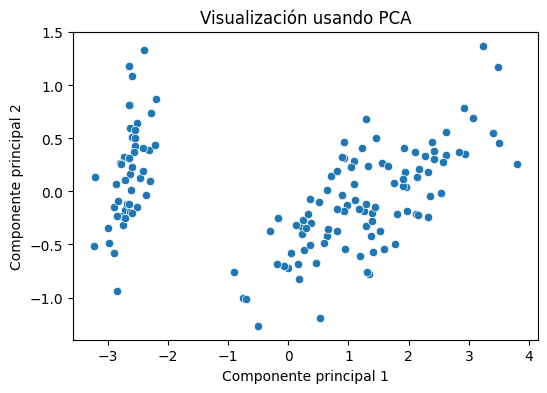

In [52]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], palette='Set2')
plt.title('Visualización usando PCA')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.show()

In [35]:
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

In [36]:
pca.components_

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

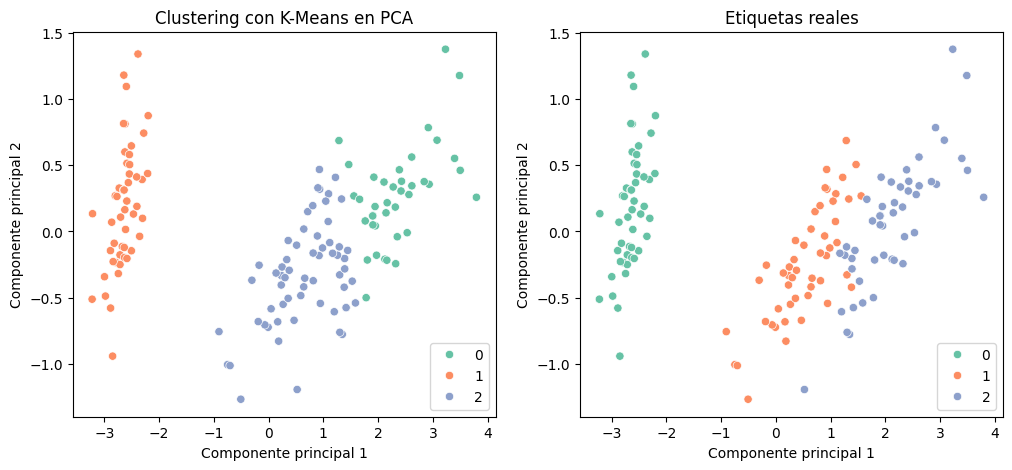

In [69]:
### CLUSTERING CON K-MEANS
from sklearn.cluster import KMeans
algoritmo_k_means = KMeans(n_clusters=3, random_state=42)
etiquetas = algoritmo_k_means.fit(X_pca)
etiquetas.labels_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=etiquetas.labels_, palette='Set2', ax=axes[0])
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set2', ax=axes[1])


axes[0].set_title('Clustering con K-Means en PCA')
axes[0].set_xlabel('Componente principal 1')
axes[0].set_ylabel('Componente principal 2')

axes[1].set_title('Etiquetas reales')
axes[1].set_xlabel('Componente principal 1')
axes[1].set_ylabel('Componente principal 2')
plt.show()


In [74]:
# 3. Función para generar el Biplot
def biplot(score, coeff, labels=None, target_clusters=None):
    plt.figure(figsize=(12, 8))
    
    # Coordenadas de los componentes principales (puntos de dispersión)
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0] # Número de variables
    
    # Escalar los puntos para que convivan en el mismo espacio que los vectores (las flechas)
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    
    # Graficar los jugadores, coloreados por su clúster de K-Means
    plt.scatter(xs * scalex, ys * scaley, c=target_clusters, cmap='viridis', alpha=0.5)
    
    # Graficar los vectores (cargas de las variables)
    for i in range(n):
        # Flecha del vector
        plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], color='red', alpha=0.8,
                  head_width=0.015, head_length=0.02)
        # Etiqueta de la variable
        if labels is not None:
            plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, labels[i], color='darkred', 
                     ha='right', va='center', fontsize=12, fontweight='bold')
    
    # Añadir los porcentajes de varianza explicada en los ejes
    var_pc1 = pca.explained_variance_ratio_[0] * 100
    var_pc2 = pca.explained_variance_ratio_[1] * 100
    
    plt.xlabel(f"PC1 ({var_pc1:.1f}% Varianza Explicada)")
    plt.ylabel(f"PC2 ({var_pc2:.1f}% Varianza Explicada)")
    plt.title("Biplot: Jugadores y Direcciones de las Variables")
    
    # Dibujar líneas en el origen (0,0) para guiar la vista
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.axvline(0, color='gray', linestyle='--', linewidth=1)
    plt.grid(alpha=0.3)
    plt.show()

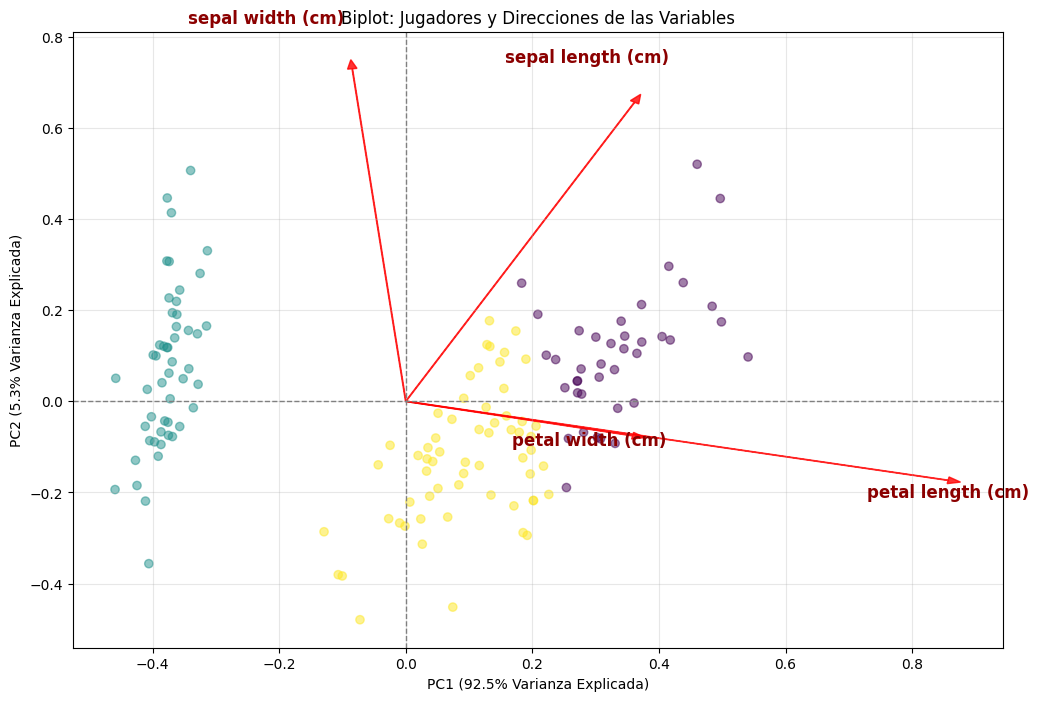

In [75]:
import numpy as np
# 4. Ejecutar el gráfico
# Pasamos la matriz transpuesta de pca.components_ para que cada fila sea un vector x,y
biplot(X_pca, np.transpose(pca.components_), labels=iris.feature_names, target_clusters=etiquetas.labels_)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24164\2223535263.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], palette='Paired')


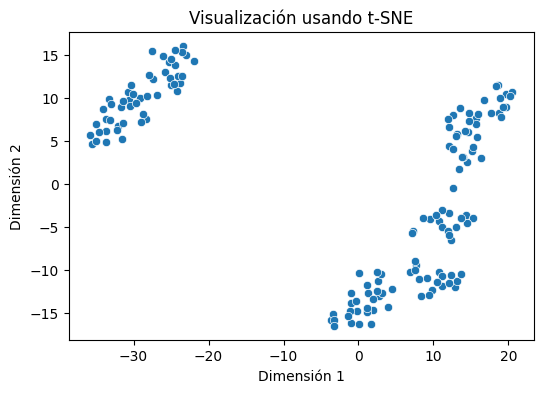

In [37]:
# Aplicamos t-SNE para ver si las agrupaciones son más evidentes
tsne = TSNE(n_components=2, perplexity=15)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(6,4))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], palette='Paired')
plt.title('Visualización usando t-SNE')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.show()